# Percentile Method / Winsorixation Techniques


In [1]:
import numpy as np
import pandas as pd
from narwhals import read_csv

In [3]:
df = pd.read_csv("weight-height.csv")
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [4]:
df.shape

(10000, 3)

In [5]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


In [6]:
import seaborn as sns

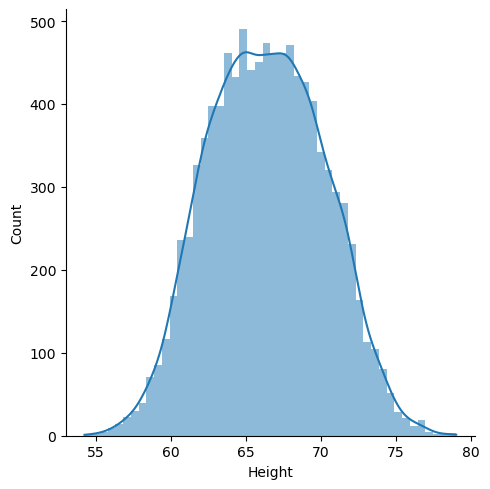

In [32]:
sns.displot(df['Height'], kde=True, edgecolor=None)  # same color manually

<Axes: xlabel='Height'>

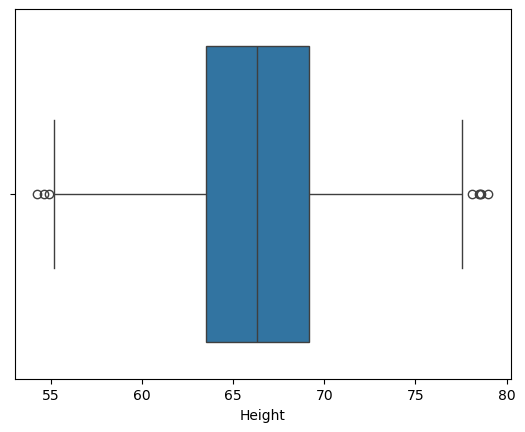

In [10]:
sns.boxplot(df['Height'], orient='h')

In [13]:
upr_lmt = df['Height'].quantile(0.99)
upr_lmt

np.float64(74.7857900583366)

In [14]:
lwr_lmt = df['Height'].quantile(0.01)
lwr_lmt

np.float64(58.13441158671655)

In [17]:
df[(df['Height'] >= 74.78) | (df['Height'] <= 58.13)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


Trimming

In [21]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [22]:
new_df['Height'].describe()

count    9799.000000
mean       66.363507
std         3.644267
min        58.134496
25%        63.577147
50%        66.317899
75%        69.119859
max        74.767447
Name: Height, dtype: float64

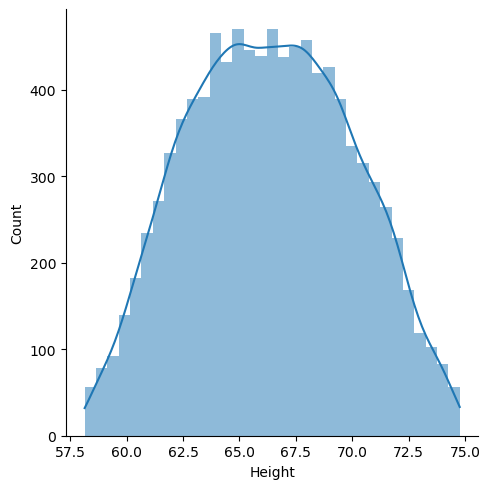

In [31]:
sns.displot(new_df['Height'], kde=True, edgecolor=None)

<Axes: xlabel='Height'>

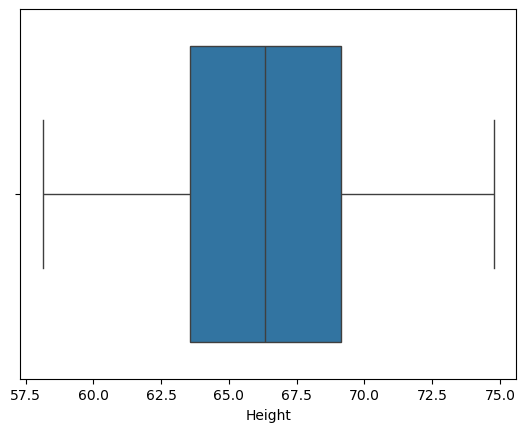

In [33]:
sns.boxplot(new_df['Height'], orient='h')

## Winsorization Method ( Capping in percentile )

In [34]:
df["Height"] = np.where(
    df['Height'] >= upr_lmt,
    upr_lmt,
    np.where(
        df['Height'] <= lwr_lmt,
        lwr_lmt,
        df['Height']
    )
)

In [35]:
df.shape

(10000, 3)

In [36]:
df['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

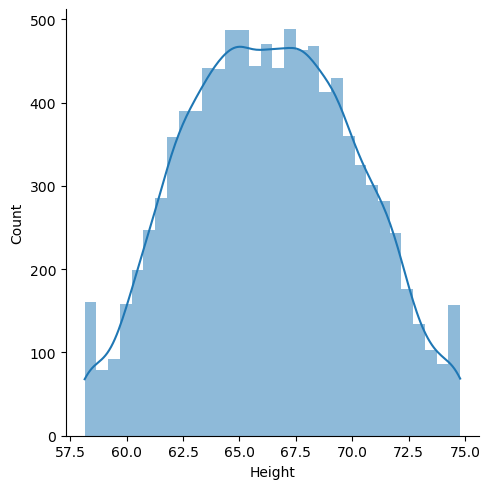

In [37]:
sns.displot(df['Height'], kde=True, edgecolor=None)

<Axes: xlabel='Height'>

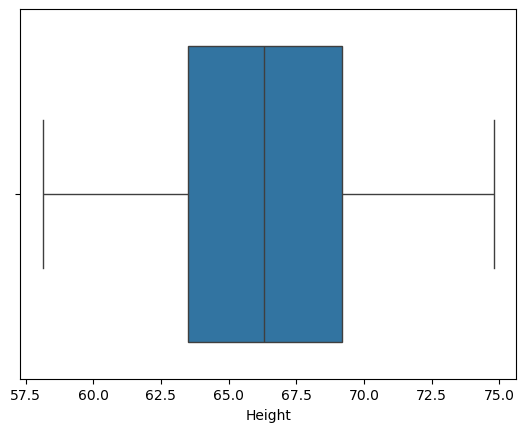

In [38]:
sns.boxplot(df['Height'], orient='h')